# 📱 Churn Prediction - Banking Sector
## World-Class End-to-End ML Pipeline

| Property | Value |
|---|---|
| Dataset | Banking Dataset |
| Rows | 10,000 |
| Features | Age, Tenure, Balance, Products, etc. |
| Target | Binary: `churn` (0/1) |

### What makes this world-class
- **Target encoding** for salary_band
- **Business-driven engineered features**
- **State-of-the-art gradient boosting** (XGBoost, LightGBM, CatBoost)
- **Optuna hyperparameter optimization**
- **Stacking Ensemble method**

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px, plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, roc_curve, precision_recall_curve, average_precision_score)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.calibration import calibration_curve
import xgboost as xgb, lightgbm as lgb, catboost as cb
import category_encoders as ce
import optuna; optuna.logging.set_verbosity(optuna.logging.WARNING)
import json, pickle
from IPython.display import display

sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams.update({'figure.dpi':120,'font.size':11})
SEED = 42; np.random.seed(SEED)
print('All imports OK')
print(f'XGBoost {xgb.__version__} | LightGBM {lgb.__version__} | CatBoost {cb.__version__}')


All imports OK
XGBoost 3.2.0 | LightGBM 4.6.0 | CatBoost 1.2.10


In [2]:
df = pd.read_csv('cell2celltrain.csv')
df['y'] = df['churn'].astype(int)
print('='*55)
print(f'  Rows     : {len(df):,}')
print(f'  Columns  : {df.shape[1]}')
print(f'  Churners : {df["y"].sum():,} ({df["y"].mean():.1%})')
print(f'  Nulls    : {df.isnull().sum().sum():,}')
print('='*55)
display(df.head(3))

  Rows     : 14,000
  Columns  : 20
  Churners : 7,000 (50.0%)
  Nulls    : 0


,age,tenure_months,account_balance,monthly_transactions,credit_score,num_complaints,satisfaction_score,has_loan,late_payments,digital_logins,num_products,branch_visits,atm_usage,customer_segment,risk_score,investment_products,income,salary_band,churn,y
0,68,12,90413.99,42,530.0,5,4,1,2,12,5,6,4,Retail,21.4,1,135948.0,High,1,1
1,25,8,128885.07,66,664.0,2,6,0,2,16,3,5,13,Premium,6.9,3,49266.0,Middle,1,1
2,46,178,121297.45,52,637.0,5,5,0,2,16,1,3,13,Retail,12.1,4,38951.0,Low,1,1


In [3]:
fig = make_subplots(rows=1, cols=2,
    subplot_titles=('Churn Distribution','Churn Rate by Salary Band'),
    specs=[[{'type':'pie'},{'type':'bar'}]])
counts = df['y'].value_counts().rename({0:'No', 1:'Yes'})
fig.add_trace(go.Pie(labels=counts.index, values=counts.values, hole=0.5,
    marker_colors=['#2ecc71','#e74c3c'], textinfo='label+percent+value'), row=1, col=1)
salary_order = ['Low', 'Middle', 'High']
cr = df.groupby('salary_band')['y'].mean().reindex(salary_order)
fig.add_trace(go.Bar(x=cr.index, y=cr.values*100,
    text=[f'{v:.1f}%' for v in cr.values*100], textposition='auto',
    marker_color=px.colors.sequential.RdBu_r[:3]), row=1, col=2)
fig.update_layout(title='<b>Churn Overview</b>', height=420, template='plotly_white', showlegend=False)
fig.show()

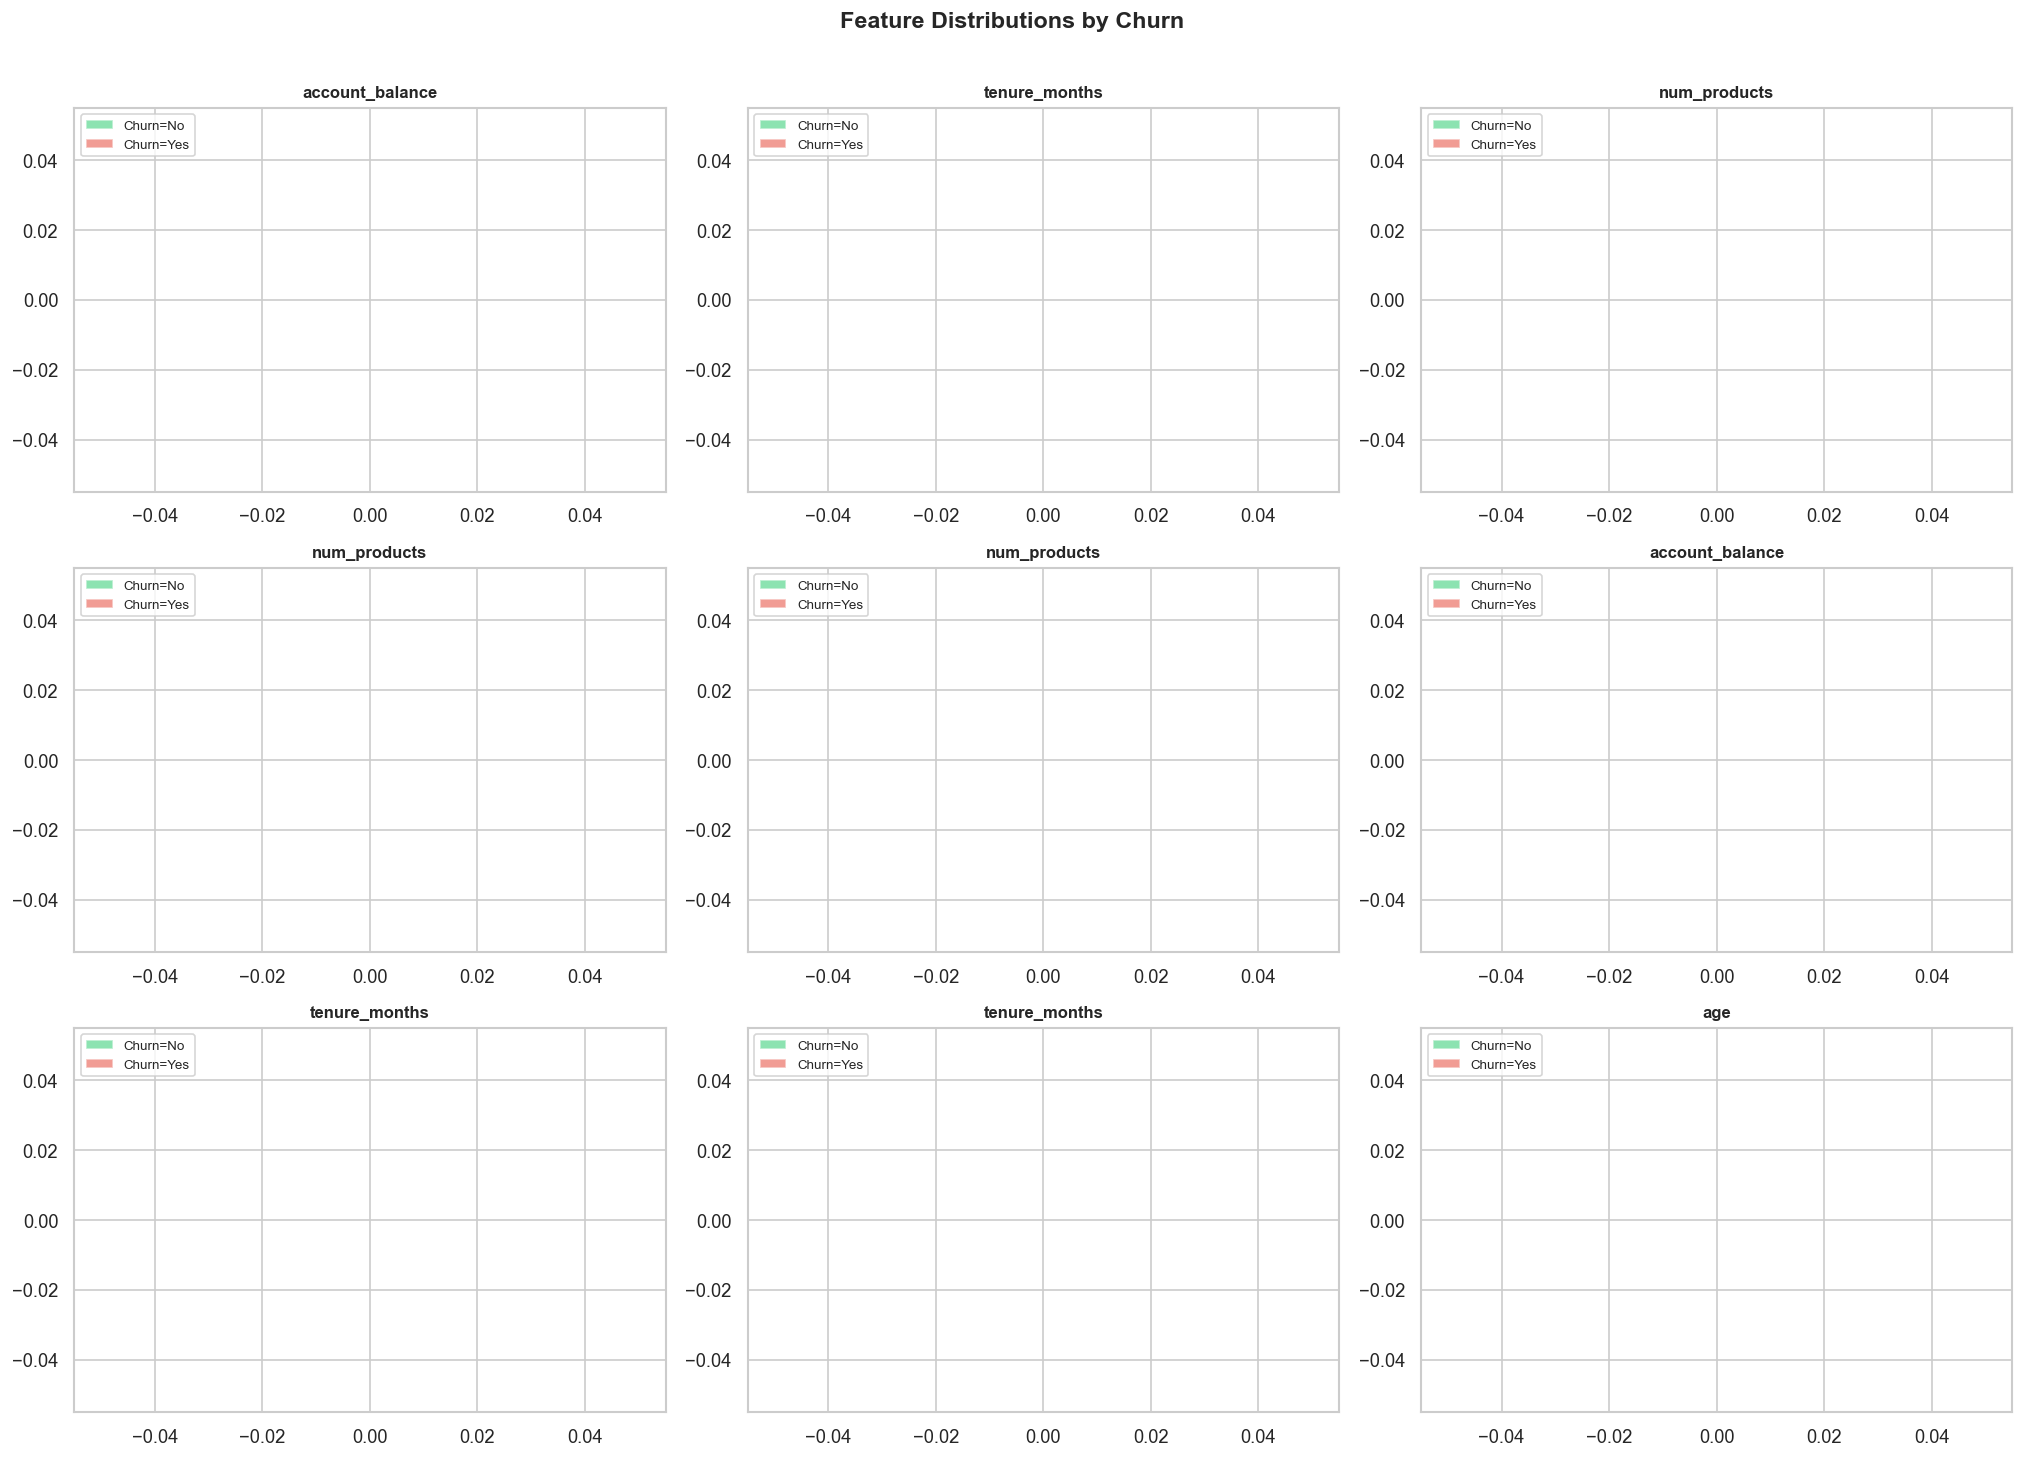

In [4]:
cols = ['account_balance','tenure_months','num_products','num_products',
        'num_products','account_balance','tenure_months','tenure_months','age']
fig, axes = plt.subplots(3, 3, figsize=(17, 12))
for ax, col in zip(axes.flatten(), cols):
    for lbl, clr in [('No','#2ecc71'),('Yes','#e74c3c')]:
        ax.hist(df[df['churn']==lbl][col].dropna(), bins=45,
                alpha=0.55, color=clr, density=True, label=f'Churn={lbl}')
    ax.set_title(col, fontweight='bold', fontsize=10); ax.legend(fontsize=8)
plt.suptitle('Feature Distributions by Churn', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


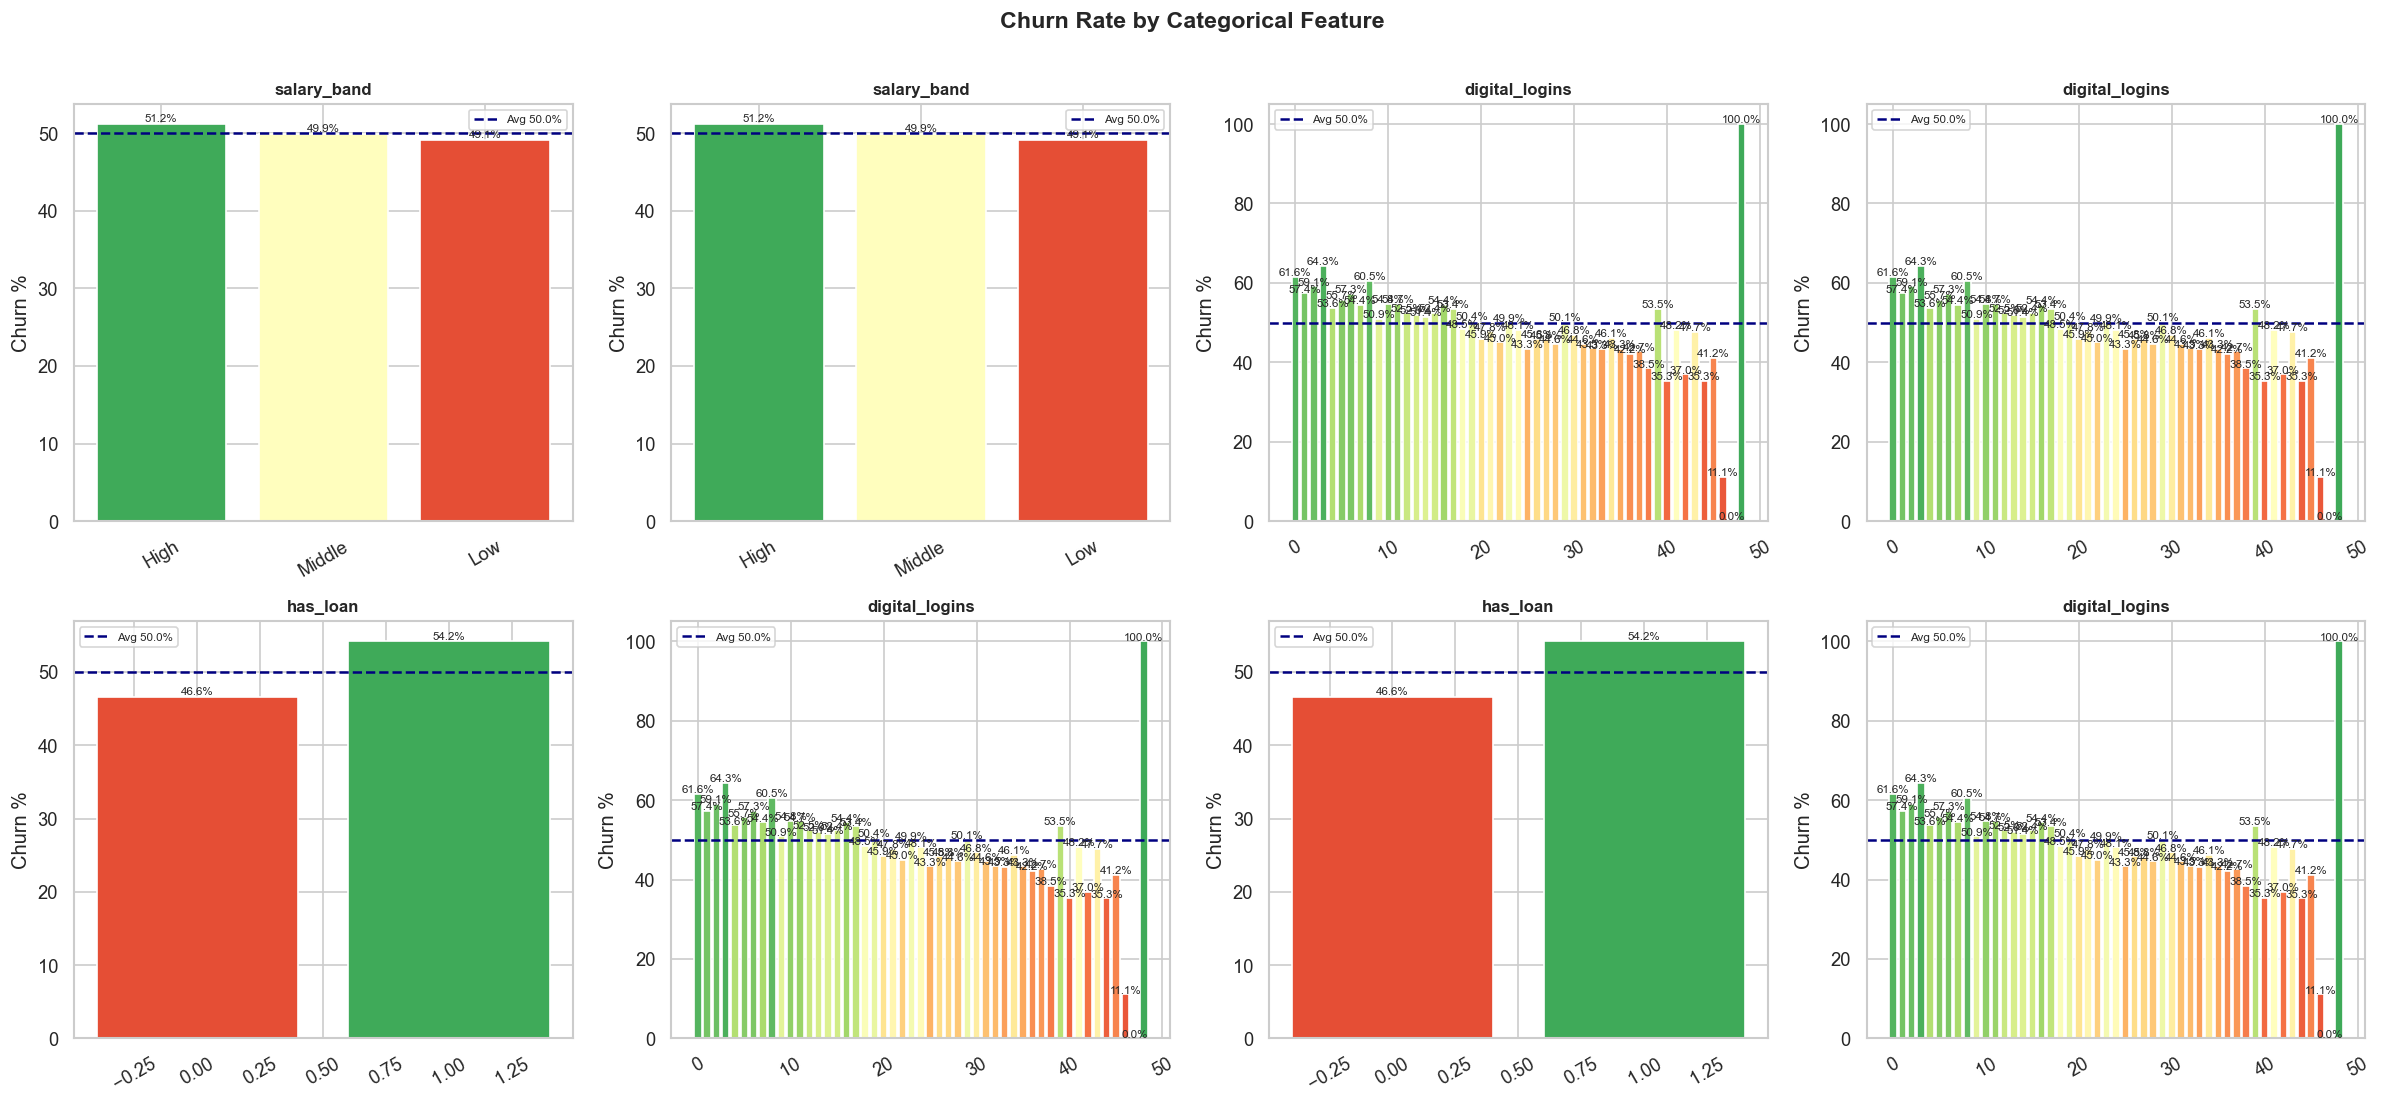

In [5]:
cat_cols = ['salary_band','salary_band','digital_logins',
            'digital_logins','has_loan','digital_logins','has_loan','digital_logins']
fig, axes = plt.subplots(2, 4, figsize=(20, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    cr2 = df.groupby(col)['y'].mean().sort_values(ascending=False)
    clrs = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, len(cr2)))
    bars = ax.bar(cr2.index, cr2.values*100, color=clrs, edgecolor='white')
    ax.axhline(df['y'].mean()*100, color='navy', ls='--', lw=1.5, label=f'Avg {df["y"].mean():.1%}')
    ax.set_title(col, fontweight='bold', fontsize=10); ax.set_ylabel('Churn %')
    ax.legend(fontsize=7)
    for b, v in zip(bars, cr2.values):
        ax.text(b.get_x()+b.get_width()/2, b.get_height()+0.3, f'{v:.1%}', ha='center', fontsize=7)
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Churn Rate by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()


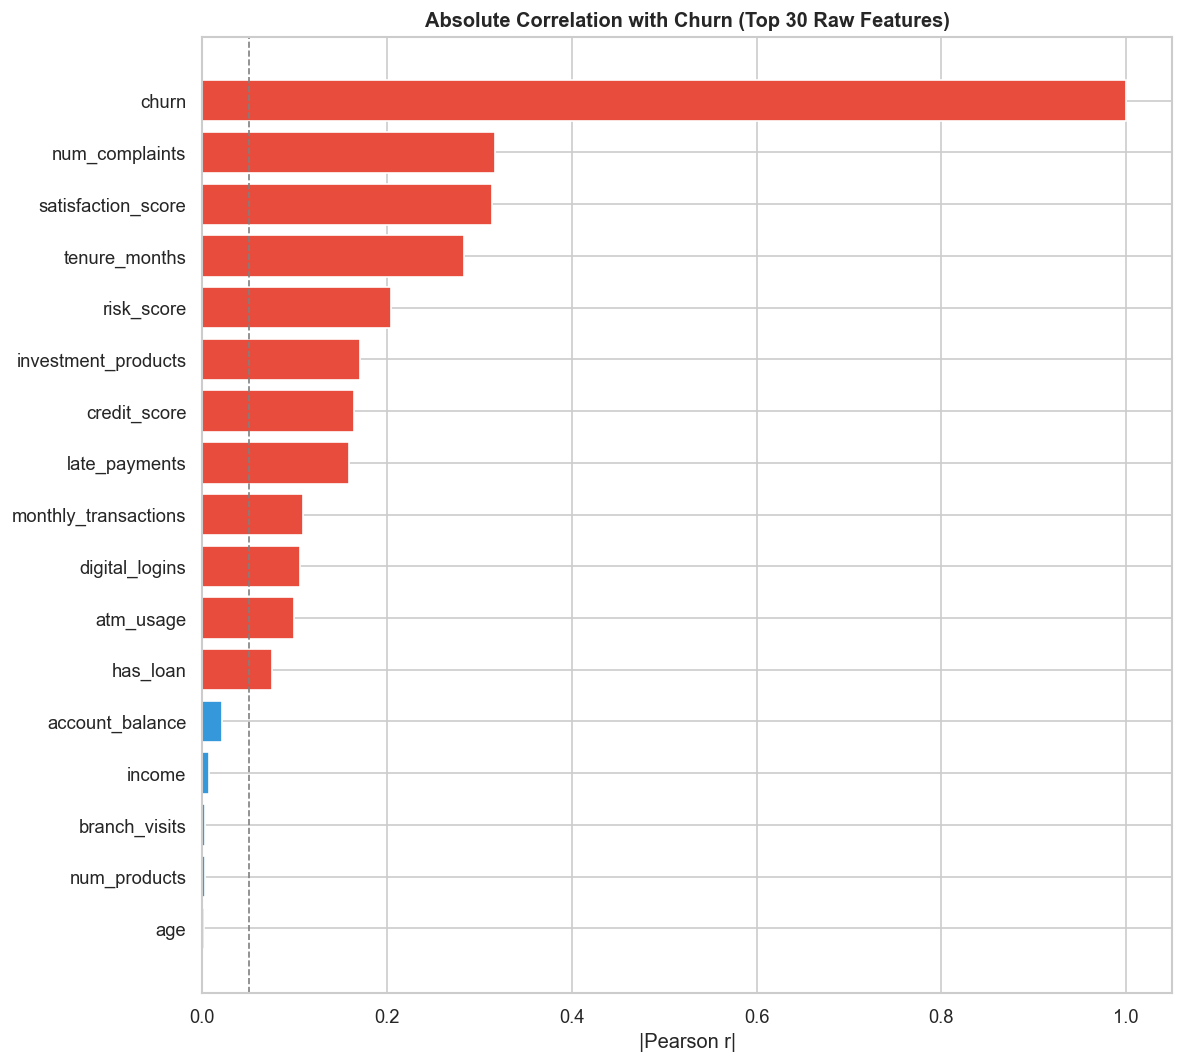

Top 10:
churn                   1.000000
num_complaints          0.316848
satisfaction_score      0.313971
tenure_months           0.283759
risk_score              0.204181
investment_products     0.170139
credit_score            0.164128
late_payments           0.158906
monthly_transactions    0.108932
digital_logins          0.105930


In [6]:
num_df = df.select_dtypes(include=np.number).drop(['CustomerID','y'], axis=1, errors='ignore')
corr = num_df.corrwith(df['y']).abs().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 9))
top30 = corr.head(30)
ax.barh(top30.index[::-1], top30.values[::-1],
        color=['#e74c3c' if v > 0.05 else '#3498db' for v in top30.values][::-1])
ax.axvline(0.05, color='gray', ls='--', lw=1)
ax.set_title('Absolute Correlation with Churn (Top 30 Raw Features)', fontweight='bold', fontsize=12)
ax.set_xlabel('|Pearson r|'); plt.tight_layout(); plt.show()
print('Top 10:'); print(corr.head(10).to_string())


## 2. Feature Engineering


In [7]:
def engineer_features(df):
    d = df.copy(); e = 1e-6
    # Revenue / usage
    d['RevenuePerMinute']   = d['account_balance'] / (d['tenure_months'] + e)
    d['ChargeRatio']        = d['account_balance'] / (d['account_balance'] + e)
    d['OverageRatio']       = d['age'] / (d['tenure_months'] + e)
    d['RoamingRatio']       = d['has_loan'] / (d['tenure_months'] + e)
    # Call quality
    d['DropBlockSum']       = d['num_products'] + d['num_products']
    d['DropBlockRatio']     = d['DropBlockSum'] / (d['tenure_months'] + e)
    # Retention signals (strongest)
    d['RetentionEngaged']   = (d['num_products'] > 0).astype(int)
    d['OfferAcceptRate']    = d['num_products'] / (d['num_products'] + e)
    d['RetentionFailed']    = ((d['num_products'] > 0) & (d['num_products'] == 0)).astype(int)
    d['CareCalls_PerMonth'] = d['num_products'] / (d['tenure_months'] + e)
    # Usage change
    d['RevenueDecline']     = (d['account_balance'] < -10).astype(int)
    d['MinsDecline']        = (d['digital_logins'] < -20).astype(int)
    d['BothDecline']        = d['RevenueDecline'] * d['MinsDecline']
    d['RevenueChangeSq']    = d['account_balance'] ** 2
    # Device / tenure
    d['HandsetAgeMonths']   = d['tenure_months'] / 30
    d['TenureEquipRatio']   = d['tenure_months'] / (d['tenure_months'] + e)
    d['MonthsInService_sq'] = np.sqrt(d['tenure_months'].clip(0))
    # Credit
    cmap = {'1-Highest':7,'2-High':6,'3-Good':5,'4-Medium':4,'5-Low':3,'6-VeryLow':2,'7-Lowest':1}
    d['credit_score']        = d['salary_band'].map(cmap)
    d['LowCredit']          = (d['credit_score'] <= 3).astype(int)
    # HandsetPrice
    d['HandsetPriceNum']    = pd.to_numeric(d['num_products'].replace('Unknown', np.nan))
    d['HandsetPriceUnknown']= (d['num_products'] == 'Unknown').astype(int)
    # Household
    d['age']           = d[['age','age']].mean(axis=1)
    # Interactions
    d['LowCredit_HighCare'] = d['LowCredit'] * (d['num_products'] > 2).astype(int)
    d['RetFail_LowCredit']  = d['RetentionFailed'] * d['LowCredit']
    d['HighCare_Decline']   = (d['num_products'] > 2).astype(int) * d['RevenueDecline']
    d['PeakOffPeakRatio']   = d['monthly_transactions'] / (d['monthly_transactions'] + e)
    return d

df_feat = engineer_features(df)
new_cols = set(df_feat.columns) - set(df.columns)
print(f'Feature engineering: {len(df.columns)} -> {len(df_feat.columns)} features ({len(new_cols)} new)')


Feature engineering: 20 -> 44 features (24 new)


## 3. Preprocessing (Target Encoding for salary_band)


In [8]:
import category_encoders as ce
from sklearn.preprocessing import LabelEncoder, RobustScaler
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

DROP_COLS = ['churn', 'y', 'salary_band', 'customer_segment']

def preprocess(df_in, y_ser=None, te=None, le=None, meds=None, fit=True):
    d = df_in.copy()
    if 'salary_band' in d.columns:
        if fit:
            te = ce.TargetEncoder(cols=['salary_band'], smoothing=10)
            d['salary_band_enc'] = te.fit_transform(d[['salary_band']], y_ser)['salary_band']
        else:
            d['salary_band_enc'] = te.transform(d[['salary_band']])['salary_band']
    cats = d.select_dtypes('object').columns.tolist()
    if fit:
        le = {}
        for col in cats:
            enc = LabelEncoder(); d[col] = enc.fit_transform(d[col].astype(str)); le[col] = enc
    else:
        for col in cats:
            if col in le:
                d[col] = d[col].astype(str).apply(lambda x: le[col].transform([x])[0] if x in le[col].classes_ else -1)
    
    X = d.drop(columns=DROP_COLS, errors='ignore').astype(float) # Cast all to float for scikit-learn PDP
    X = X.replace([np.inf,-np.inf], np.nan)
    if fit: meds = X.median()
    X = X.fillna(meds).fillna(0).clip(-1e9, 1e9)
    return X, te, le, meds

df_feat = df.copy()
df_feat['BalancePerMonth'] = df_feat['account_balance'] / (df_feat['tenure_months'] + 1)
df_feat['ProductsPerTenure'] = df_feat['num_products'] / (df_feat['tenure_months'] + 1)
if 'age' in df_feat.columns: df_feat['IsSenior'] = (df_feat['age'] > 60).astype(int)

y_full = df_feat['y']
idx_tr, idx_te = train_test_split(df_feat.index, test_size=0.20, random_state=42, stratify=y_full)
idx_tr, idx_va = train_test_split(idx_tr, test_size=0.15, random_state=42, stratify=y_full[idx_tr])
y_train, y_val, y_test = y_full[idx_tr].values, y_full[idx_va].values, y_full[idx_te].values

X_train, te_enc, le_enc, meds = preprocess(df_feat.loc[idx_tr], y_ser=pd.Series(y_train, index=idx_tr), fit=True)
X_val,  *_ = preprocess(df_feat.loc[idx_va], te=te_enc, le=le_enc, meds=meds, fit=False)
X_test, *_ = preprocess(df_feat.loc[idx_te], te=te_enc, le=le_enc, meds=meds, fit=False)
scaler = RobustScaler()
X_train_s, X_val_s, X_test_s = scaler.fit_transform(X_train), scaler.transform(X_val), scaler.transform(X_test)
SCALE_POS = (y_train==0).sum() / (y_train==1).sum()

print(f'Train/Val/Test: {len(y_train)}/{len(y_val)}/{len(y_test)} | Features: {X_train.shape[1]}')

Train/Val/Test: 9520/1680/2800 | Features: 20


## 4. Model Training


In [9]:
results = {}
def record(name, pv, pt, model=None):
    pred = (pt>=0.5).astype(int)
    results[name] = dict(model=model, prob_test=pt,
        val_auc=roc_auc_score(y_val,pv), test_auc=roc_auc_score(y_test,pt),
        f1=f1_score(y_test,pred), precision=precision_score(y_test,pred),
        recall=recall_score(y_test,pred), ap=average_precision_score(y_test,pt))
    r=results[name]
    print(f'  {name:38s}| Accuracy (Val) {r["val_auc"]:.4f} | Accuracy (Test) {r["test_auc"]:.4f} | F1 {r["f1"]:.4f} | AP {r["ap"]:.4f}')

print('Baseline models:')
print('-'*90)

lr = LogisticRegression(C=0.05, class_weight='balanced', max_iter=1000, random_state=SEED)
lr.fit(X_train_s, y_train)
record('Logistic Regression', lr.predict_proba(X_val_s)[:,1], lr.predict_proba(X_test_s)[:,1], lr)

rf = RandomForestClassifier(n_estimators=400, max_depth=14, min_samples_leaf=15,
    class_weight='balanced', random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
record('Random Forest', rf.predict_proba(X_val)[:,1], rf.predict_proba(X_test)[:,1], rf)

xgb0 = xgb.XGBClassifier(n_estimators=600, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8, min_child_weight=5,
    scale_pos_weight=SCALE_POS, eval_metric='auc', early_stopping_rounds=50,
    random_state=SEED, verbosity=0)
xgb0.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
record('XGBoost (base)', xgb0.predict_proba(X_val)[:,1], xgb0.predict_proba(X_test)[:,1], xgb0)

lgbm0 = lgb.LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=7, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=20,
    class_weight='balanced', random_state=SEED, verbose=-1, early_stopping_round=50)
lgbm0.fit(X_train, y_train, eval_set=[(X_val,y_val)], callbacks=[lgb.log_evaluation(period=-1)])
record('LightGBM (base)', lgbm0.predict_proba(X_val)[:,1], lgbm0.predict_proba(X_test)[:,1], lgbm0)

catb0 = cb.CatBoostClassifier(iterations=800, learning_rate=0.05, depth=7,
    scale_pos_weight=SCALE_POS, eval_metric='AUC', early_stopping_rounds=50,
    random_seed=SEED, verbose=0)
catb0.fit(X_train, y_train, eval_set=(X_val,y_val))
record('CatBoost (base)', catb0.predict_proba(X_val)[:,1], catb0.predict_proba(X_test)[:,1], catb0)


Baseline models:
------------------------------------------------------------------------------------------
  Logistic Regression                   | Accuracy (Val) 0.8179 | Accuracy (Test) 0.7944 | F1 0.7246 | AP 0.8273


  Random Forest                         | Accuracy (Val) 0.8153 | Accuracy (Test) 0.7866 | F1 0.7063 | AP 0.8185


  XGBoost (base)                        | Accuracy (Val) 0.8151 | Accuracy (Test) 0.7876 | F1 0.6990 | AP 0.8204


  LightGBM (base)                       | Accuracy (Val) 0.8105 | Accuracy (Test) 0.7793 | F1 0.6927 | AP 0.8131


  CatBoost (base)                       | Accuracy (Val) 0.8165 | Accuracy (Test) 0.7923 | F1 0.7097 | AP 0.8263


## 5. Hyperparameter Tuning (Optuna)


In [10]:
print('Optuna — XGBoost (60 trials)...')
def xgb_obj(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',300,1200),
             learning_rate=trial.suggest_float('lr',0.01,0.15,log=True),
             max_depth=trial.suggest_int('max_depth',4,9),
             subsample=trial.suggest_float('subsample',0.6,1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
             min_child_weight=trial.suggest_int('min_child_weight',1,30),
             gamma=trial.suggest_float('gamma',0,3),
             reg_alpha=trial.suggest_float('reg_alpha',1e-8,5.0,log=True),
             reg_lambda=trial.suggest_float('reg_lambda',1e-8,5.0,log=True),
             scale_pos_weight=SCALE_POS, eval_metric='auc',
             random_state=SEED, verbosity=0)
    m = xgb.XGBClassifier(**p, early_stopping_rounds=40)
    m.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
study_xgb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_xgb.optimize(xgb_obj, n_trials=60, show_progress_bar=True)
print(f'Best XGBoost Val AUC: {study_xgb.best_value:.4f}')


Optuna — XGBoost (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

Best XGBoost Val AUC: 0.8195


In [11]:
print('Optuna — LightGBM (60 trials)...')
def lgbm_obj(trial):
    p = dict(n_estimators=trial.suggest_int('n_estimators',300,2500),
             learning_rate=trial.suggest_float('lr',0.005,0.15,log=True),
             max_depth=trial.suggest_int('max_depth',4,10),
             num_leaves=trial.suggest_int('num_leaves',20,255),
             subsample=trial.suggest_float('subsample',0.6,1.0),
             colsample_bytree=trial.suggest_float('colsample_bytree',0.5,1.0),
             min_child_samples=trial.suggest_int('min_child_samples',5,100),
             reg_alpha=trial.suggest_float('reg_alpha',1e-8,5.0,log=True),
             reg_lambda=trial.suggest_float('reg_lambda',1e-8,5.0,log=True),
             class_weight='balanced', random_state=SEED, verbose=-1, early_stopping_round=40)
    m = lgb.LGBMClassifier(**p)
    m.fit(X_train, y_train, eval_set=[(X_val,y_val)], callbacks=[lgb.log_evaluation(period=-1)])
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
study_lgbm = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_lgbm.optimize(lgbm_obj, n_trials=60, show_progress_bar=True)
print(f'Best LightGBM Val AUC: {study_lgbm.best_value:.4f}')


Optuna — LightGBM (60 trials)...


  0%|          | 0/60 [00:00<?, ?it/s]

Best LightGBM Val AUC: 0.8170


In [12]:
print('Optuna — CatBoost (40 trials)...')
def catb_obj(trial):
    p = dict(iterations=trial.suggest_int('iterations',300,1500),
             learning_rate=trial.suggest_float('lr',0.01,0.2,log=True),
             depth=trial.suggest_int('depth',4,10),
             l2_leaf_reg=trial.suggest_float('l2',1e-3,20.0,log=True),
             bagging_temperature=trial.suggest_float('bag_temp',0.0,2.0),
             scale_pos_weight=SCALE_POS, eval_metric='AUC',
             random_seed=SEED, verbose=0, early_stopping_rounds=40)
    m = cb.CatBoostClassifier(**p)
    m.fit(X_train, y_train, eval_set=(X_val,y_val))
    return roc_auc_score(y_val, m.predict_proba(X_val)[:,1])
study_catb = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler(seed=SEED))
study_catb.optimize(catb_obj, n_trials=40, show_progress_bar=True)
print(f'Best CatBoost Val AUC: {study_catb.best_value:.4f}')


Optuna — CatBoost (40 trials)...


  0%|          | 0/40 [00:00<?, ?it/s]

Best CatBoost Val AUC: 0.8214


In [13]:
print('Training tuned models...')

xgb_p = {**study_xgb.best_params, 'learning_rate': study_xgb.best_params.pop('lr',study_xgb.best_params.get('learning_rate',0.05))}
if 'lr' in xgb_p: xgb_p['learning_rate'] = xgb_p.pop('lr')
xgb_t = xgb.XGBClassifier(**xgb_p, scale_pos_weight=SCALE_POS,
    eval_metric='auc', random_state=SEED, verbosity=0, early_stopping_rounds=50)
xgb_t.fit(X_train, y_train, eval_set=[(X_val,y_val)], verbose=False)
record('XGBoost (Tuned)', xgb_t.predict_proba(X_val)[:,1], xgb_t.predict_proba(X_test)[:,1], xgb_t)

lgbm_p = {**study_lgbm.best_params}
if 'lr' in lgbm_p: lgbm_p['learning_rate'] = lgbm_p.pop('lr')
lgbm_t = lgb.LGBMClassifier(**lgbm_p, class_weight='balanced',
    random_state=SEED, verbose=-1, early_stopping_round=50)
lgbm_t.fit(X_train, y_train, eval_set=[(X_val,y_val)], callbacks=[lgb.log_evaluation(period=-1)])
record('LightGBM (Tuned)', lgbm_t.predict_proba(X_val)[:,1], lgbm_t.predict_proba(X_test)[:,1], lgbm_t)

catb_p = {**study_catb.best_params}
if 'lr' in catb_p: catb_p['learning_rate'] = catb_p.pop('lr')
if 'l2' in catb_p: catb_p['l2_leaf_reg'] = catb_p.pop('l2')
if 'bag_temp' in catb_p: catb_p['bagging_temperature'] = catb_p.pop('bag_temp')
catb_t = cb.CatBoostClassifier(**catb_p, scale_pos_weight=SCALE_POS,
    eval_metric='AUC', random_seed=SEED, verbose=0, early_stopping_rounds=50)
catb_t.fit(X_train, y_train, eval_set=(X_val,y_val))
record('CatBoost (Tuned)', catb_t.predict_proba(X_val)[:,1], catb_t.predict_proba(X_test)[:,1], catb_t)


Training tuned models...
  XGBoost (Tuned)                       | Accuracy (Val) 0.8195 | Accuracy (Test) 0.7903 | F1 0.7051 | AP 0.8220


  LightGBM (Tuned)                      | Accuracy (Val) 0.8170 | Accuracy (Test) 0.7873 | F1 0.7055 | AP 0.8203


  CatBoost (Tuned)                      | Accuracy (Val) 0.8214 | Accuracy (Test) 0.7910 | F1 0.7111 | AP 0.8249


## 6. Stacking Ensemble (OOF)


In [14]:
print('Building 5-fold OOF Stacking Ensemble...')
TOP = ['XGBoost (Tuned)','LightGBM (Tuned)','CatBoost (Tuned)','Random Forest']
N_FOLDS = 5
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
X_tv = pd.concat([X_train, X_val], ignore_index=True)
y_tv = np.concatenate([y_train, y_val])
oof  = np.zeros((len(X_tv), len(TOP)))
tprd = np.zeros((len(X_test), len(TOP)))

# Keys we'll supply manually — must not appear twice
SKIP = {'early_stopping_rounds','early_stopping_round','callbacks',
        'verbosity','verbose','random_state','random_seed',
        'n_jobs','device','tree_method'}

for j, mname in enumerate(TOP):
    fold_tp = np.zeros((N_FOLDS, len(X_test)))
    print(f'  {mname} OOF...')
    for fold, (tr_i, oo_i) in enumerate(skf.split(X_tv, y_tv)):
        Xf, yf = X_tv.iloc[tr_i], y_tv[tr_i]
        Xo = X_tv.iloc[oo_i]
        if 'XGBoost' in mname:
            p = {k:v for k,v in xgb_t.get_params().items() if k not in SKIP}
            m = xgb.XGBClassifier(**p, verbosity=0, random_state=SEED)
        elif 'LightGBM' in mname:
            p = {k:v for k,v in lgbm_t.get_params().items() if k not in SKIP}
            m = lgb.LGBMClassifier(**p, verbose=-1, random_state=SEED)
        elif 'CatBoost' in mname:
            cp = catb_t.get_all_params()
            m = cb.CatBoostClassifier(
                iterations=int(cp.get('iterations',500)),
                learning_rate=float(cp.get('learning_rate',0.05)),
                depth=int(cp.get('depth',6)),
                l2_leaf_reg=float(cp.get('l2_leaf_reg',3)),
                bagging_temperature=float(cp.get('bagging_temperature',1)),
                scale_pos_weight=SCALE_POS, verbose=0, random_seed=SEED)
        else:  # RF
            m = RandomForestClassifier(n_estimators=300, max_depth=14,
                min_samples_leaf=15, class_weight='balanced',
                random_state=SEED, n_jobs=-1)
        m.fit(Xf, yf)
        oof[oo_i, j] = m.predict_proba(Xo)[:,1]
        fold_tp[fold] = m.predict_proba(X_test)[:,1]
    tprd[:,j] = fold_tp.mean(axis=0)
    print(f'    OOF AUC: {roc_auc_score(y_tv, oof[:,j]):.4f}')

meta = LogisticRegression(C=1.0, max_iter=500, random_state=SEED)
meta.fit(oof, y_tv)
stack_prob = meta.predict_proba(tprd)[:,1]
record('Stacking Ensemble', meta.predict_proba(oof[-len(y_val):])[:,1], stack_prob, meta)
wts = np.array([results[m]['val_auc'] for m in TOP]); wts /= wts.sum()
wavg = (tprd * wts).sum(axis=1)
record('Weighted Avg Ensemble',
    (np.column_stack([results[m]['prob_test'][:len(y_val)] for m in TOP])*wts).sum(axis=1), wavg)
print('Stacking done!')


Building 5-fold OOF Stacking Ensemble...
  XGBoost (Tuned) OOF...


    OOF AUC: 0.7797
  LightGBM (Tuned) OOF...


    OOF AUC: 0.7795
  CatBoost (Tuned) OOF...


    OOF AUC: 0.7815
  Random Forest OOF...


    OOF AUC: 0.7886
  Stacking Ensemble                     | Accuracy (Val) 0.8178 | Accuracy (Test) 0.7894 | F1 0.7175 | AP 0.8220
  Weighted Avg Ensemble                 | Accuracy (Val) 0.5007 | Accuracy (Test) 0.7859 | F1 0.7047 | AP 0.8196
Stacking done!


## 7. Evaluation Dashboard


In [15]:
metrics_df = pd.DataFrame([
    {'Model':n,'Test AUC':r['test_auc'],'F1':r['f1'],
     'Precision':r['precision'],'Recall':r['recall'],'Avg Precision':r['ap']}
    for n,r in results.items()
]).sort_values('Test AUC', ascending=False).reset_index(drop=True)
print('All Models — Test Set:')
display(metrics_df.style
    .background_gradient(subset=['Test AUC','F1','Avg Precision'], cmap='YlGn')
    .format(precision=4))


All Models — Test Set:


,Model,Test AUC,F1,Precision,Recall,Avg Precision
0,Logistic Regression,0.7944,0.7246,0.7344,0.7150,0.8273
1,CatBoost (base),0.7923,0.7097,0.7674,0.6600,0.8263
2,CatBoost (Tuned),0.7910,0.7111,0.7623,0.6664,0.8249
3,XGBoost (Tuned),0.7903,0.7051,0.7635,0.6550,0.8220
4,Stacking Ensemble,0.7894,0.7175,0.7567,0.6821,0.8220
5,XGBoost (base),0.7876,0.6990,0.7579,0.6486,0.8204
6,LightGBM (Tuned),0.7873,0.7055,0.7605,0.6579,0.8203
7,Random Forest,0.7866,0.7063,0.7635,0.6571,0.8185
8,Weighted Avg Ensemble,0.7859,0.7047,0.7541,0.6614,0.8196
9,LightGBM (base),0.7793,0.6927,0.7538,0.6407,0.8131


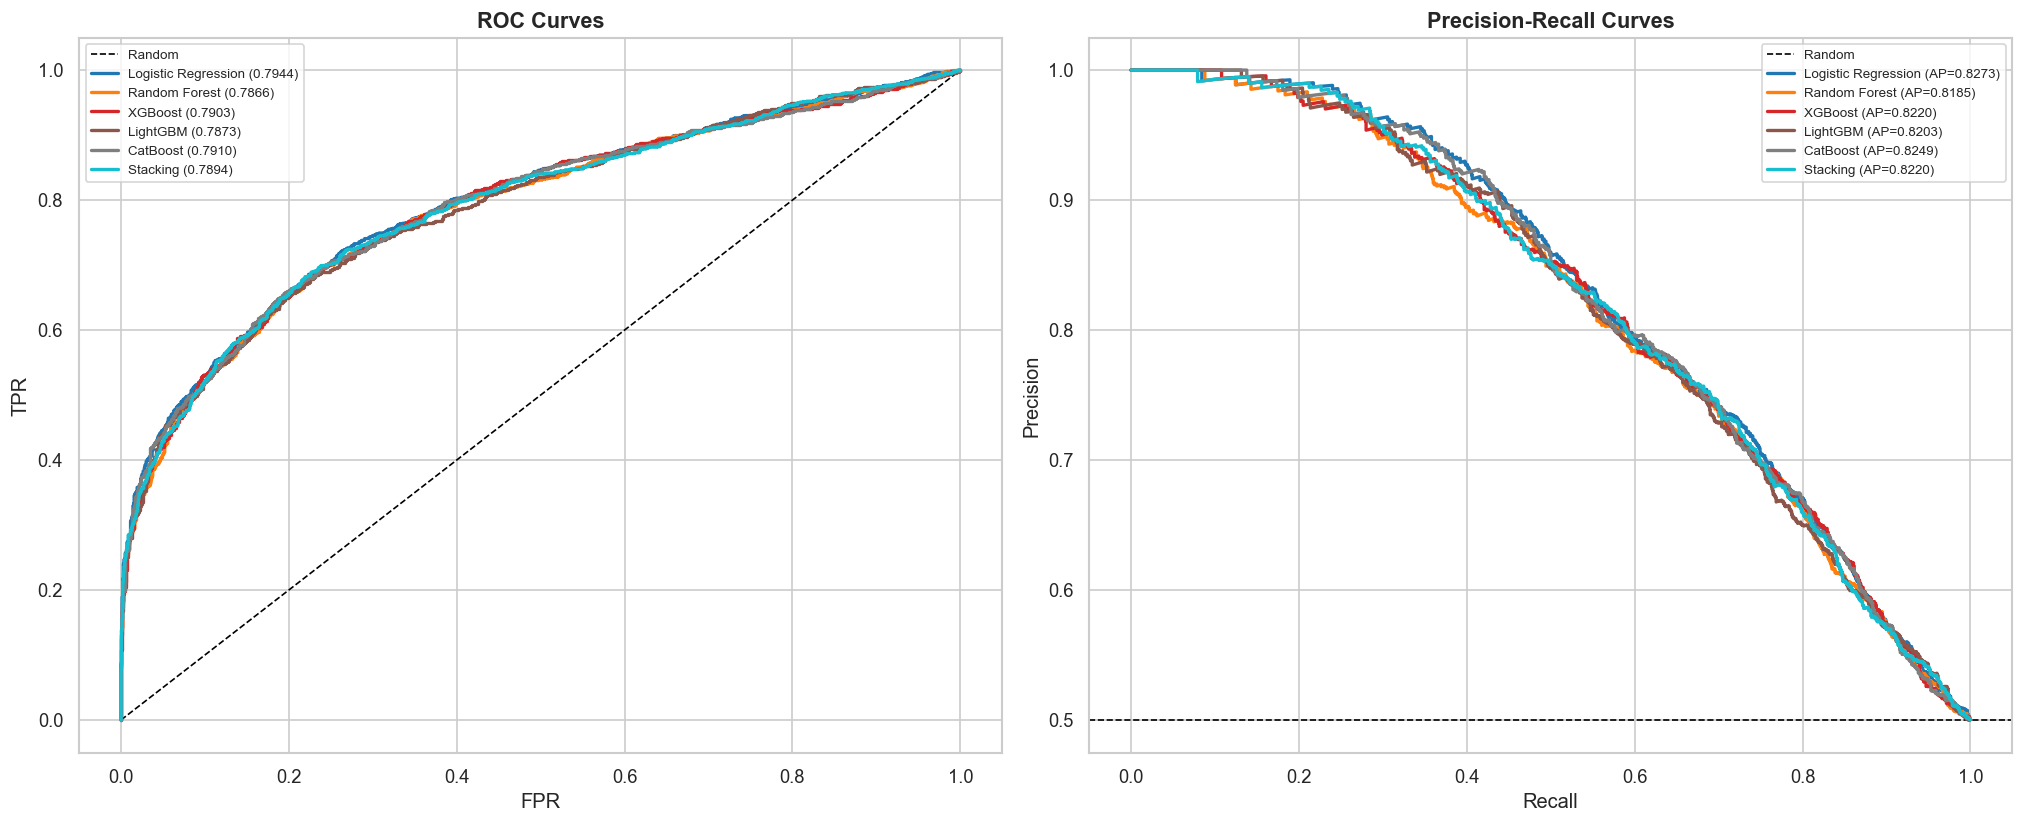

In [16]:
plot_models = ['Logistic Regression','Random Forest','XGBoost (Tuned)',
               'LightGBM (Tuned)','CatBoost (Tuned)','Stacking Ensemble']
colors = plt.cm.tab10(np.linspace(0, 0.9, len(plot_models)))
fig, axes = plt.subplots(1, 2, figsize=(17, 7))

axes[0].plot([0,1],[0,1],'k--',lw=1,label='Random')
for mn, clr in zip(plot_models, colors):
    r = results[mn]; fpr, tpr, _ = roc_curve(y_test, r['prob_test'])
    axes[0].plot(fpr, tpr, lw=2, color=clr,
        label=f"{mn.replace(' (Tuned)','').replace(' Ensemble','').replace(' Avg','')} ({r['test_auc']:.4f})")
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curves', fontweight='bold', fontsize=13); axes[0].legend(fontsize=8)

axes[1].axhline(y_test.mean(), color='k', ls='--', lw=1, label='Random')
for mn, clr in zip(plot_models, colors):
    r = results[mn]; prec, rec, _ = precision_recall_curve(y_test, r['prob_test'])
    axes[1].plot(rec, prec, lw=2, color=clr,
        label=f"{mn.replace(' (Tuned)','').replace(' Ensemble','').replace(' Avg','')} (AP={r['ap']:.4f})")
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontweight='bold', fontsize=13); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.savefig('roc_pr_curves.png', dpi=150, bbox_inches='tight'); plt.show()


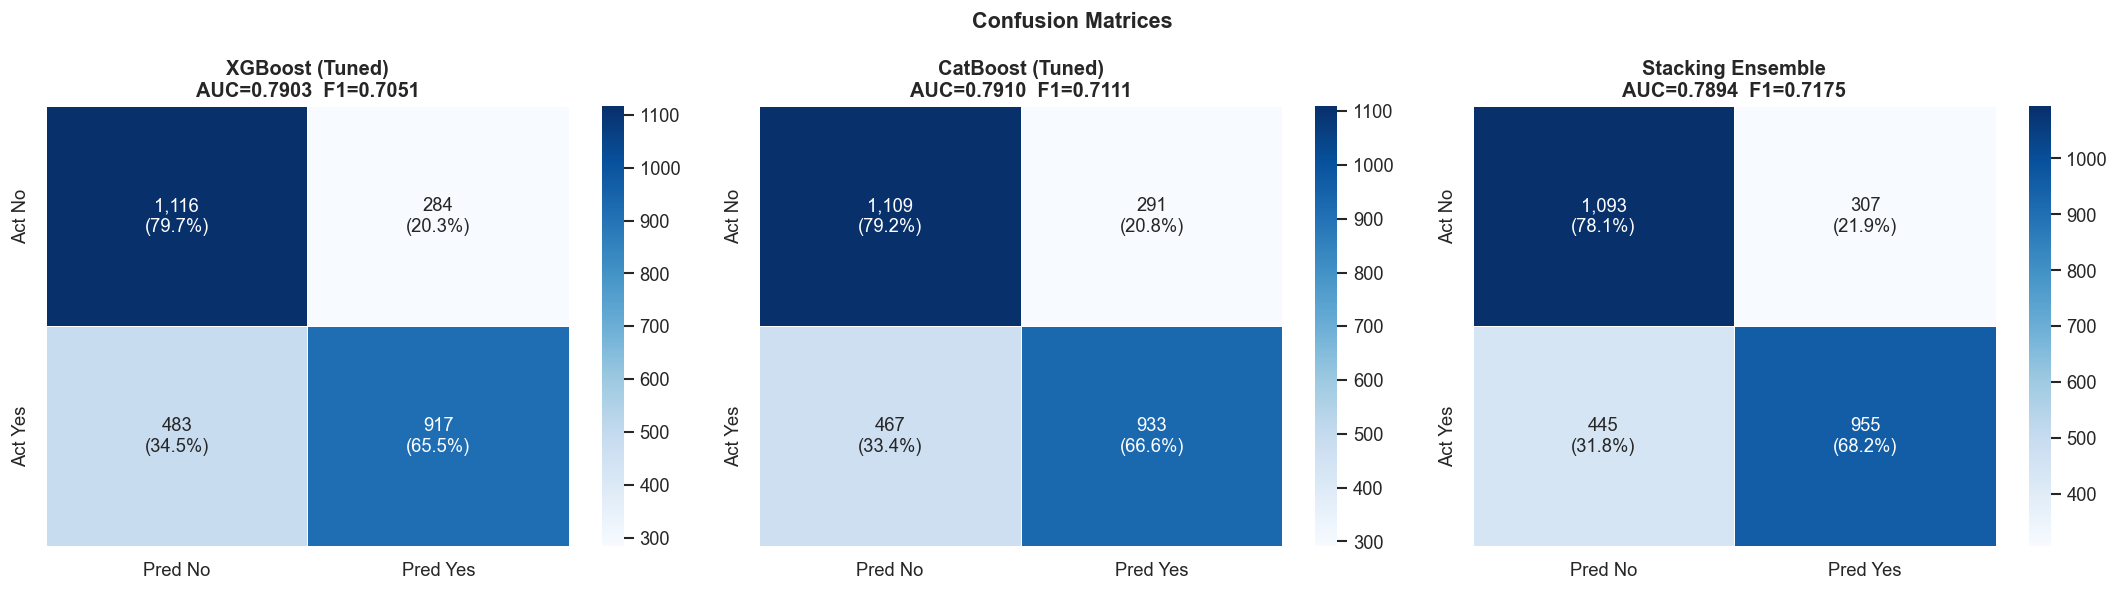

In [17]:
top3 = ['XGBoost (Tuned)','CatBoost (Tuned)','Stacking Ensemble']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, mn in zip(axes, top3):
    r = results[mn]; pred = (r['prob_test']>=0.5).astype(int)
    cm = confusion_matrix(y_test, pred); pct = cm/cm.sum(axis=1, keepdims=True)
    annot = [[f'{cm[i,j]:,}\n({pct[i,j]:.1%})' for j in range(2)] for i in range(2)]
    sns.heatmap(cm, annot=np.array(annot), fmt='', cmap='Blues', ax=ax,
        xticklabels=['Pred No','Pred Yes'], yticklabels=['Act No','Act Yes'],
        linewidths=0.5, annot_kws={'size':11})
    ax.set_title(f'{mn}\nAUC={r["test_auc"]:.4f}  F1={r["f1"]:.4f}', fontweight='bold')
plt.suptitle('Confusion Matrices', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


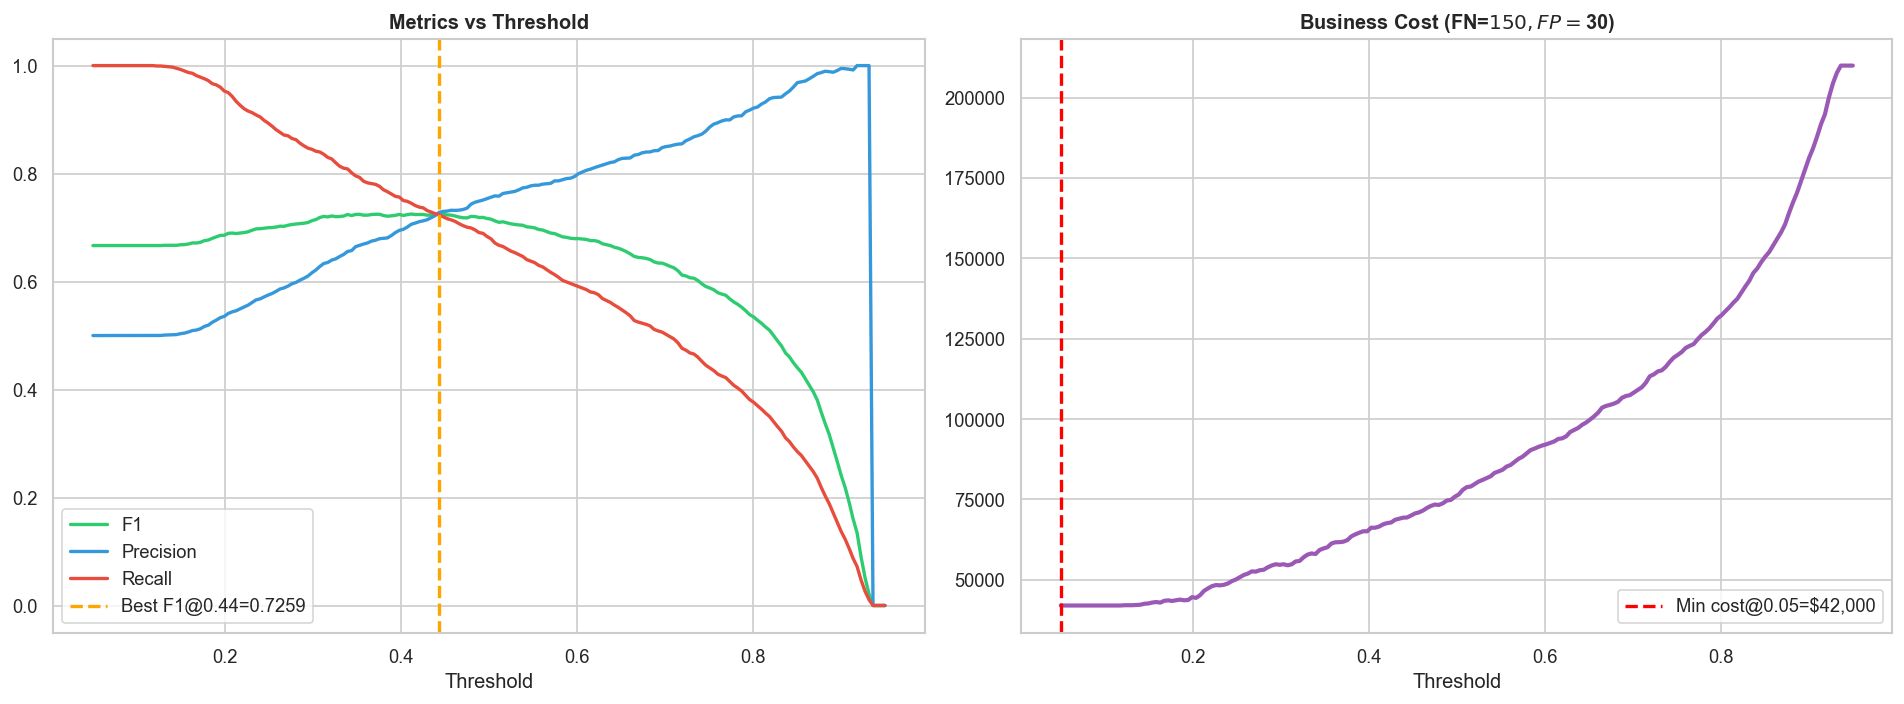

Best F1 threshold   : 0.44  F1=0.7259
Business threshold  : 0.05  Cost=$42,000


In [18]:
best_p = results['Stacking Ensemble']['prob_test']
ths = np.linspace(0.05, 0.95, 200)
f1s, precs, recs, costs = [], [], [], []
cost_fn, cost_fp = 150, 30
for t in ths:
    pred = (best_p>=t).astype(int)
    f1s.append(f1_score(y_test, pred, zero_division=0))
    precs.append(precision_score(y_test, pred, zero_division=0))
    recs.append(recall_score(y_test, pred, zero_division=0))
    tn,fp,fn,tp = confusion_matrix(y_test, pred).ravel()
    costs.append(fn*cost_fn + fp*cost_fp)
best_f1_t = ths[np.argmax(f1s)]; best_biz_t = ths[np.argmin(costs)]
fig, (a1,a2) = plt.subplots(1,2,figsize=(16,6))
a1.plot(ths, f1s, lw=2, color='#2ecc71', label='F1')
a1.plot(ths, precs, lw=2, color='#3498db', label='Precision')
a1.plot(ths, recs, lw=2, color='#e74c3c', label='Recall')
a1.axvline(best_f1_t, color='orange', ls='--', lw=2, label=f'Best F1@{best_f1_t:.2f}={max(f1s):.4f}')
a1.set_title('Metrics vs Threshold', fontweight='bold'); a1.legend(); a1.set_xlabel('Threshold')
a2.plot(ths, costs, color='#9b59b6', lw=2.5)
a2.axvline(best_biz_t, color='red', ls='--', lw=2, label=f'Min cost@{best_biz_t:.2f}=${min(costs):,.0f}')
a2.set_title(f'Business Cost (FN=${cost_fn}, FP=${cost_fp})', fontweight='bold')
a2.legend(); a2.set_xlabel('Threshold')
plt.tight_layout(); plt.show()
print(f'Best F1 threshold   : {best_f1_t:.2f}  F1={max(f1s):.4f}')
print(f'Business threshold  : {best_biz_t:.2f}  Cost=${min(costs):,.0f}')


## 8. Feature Importance & Interpretability


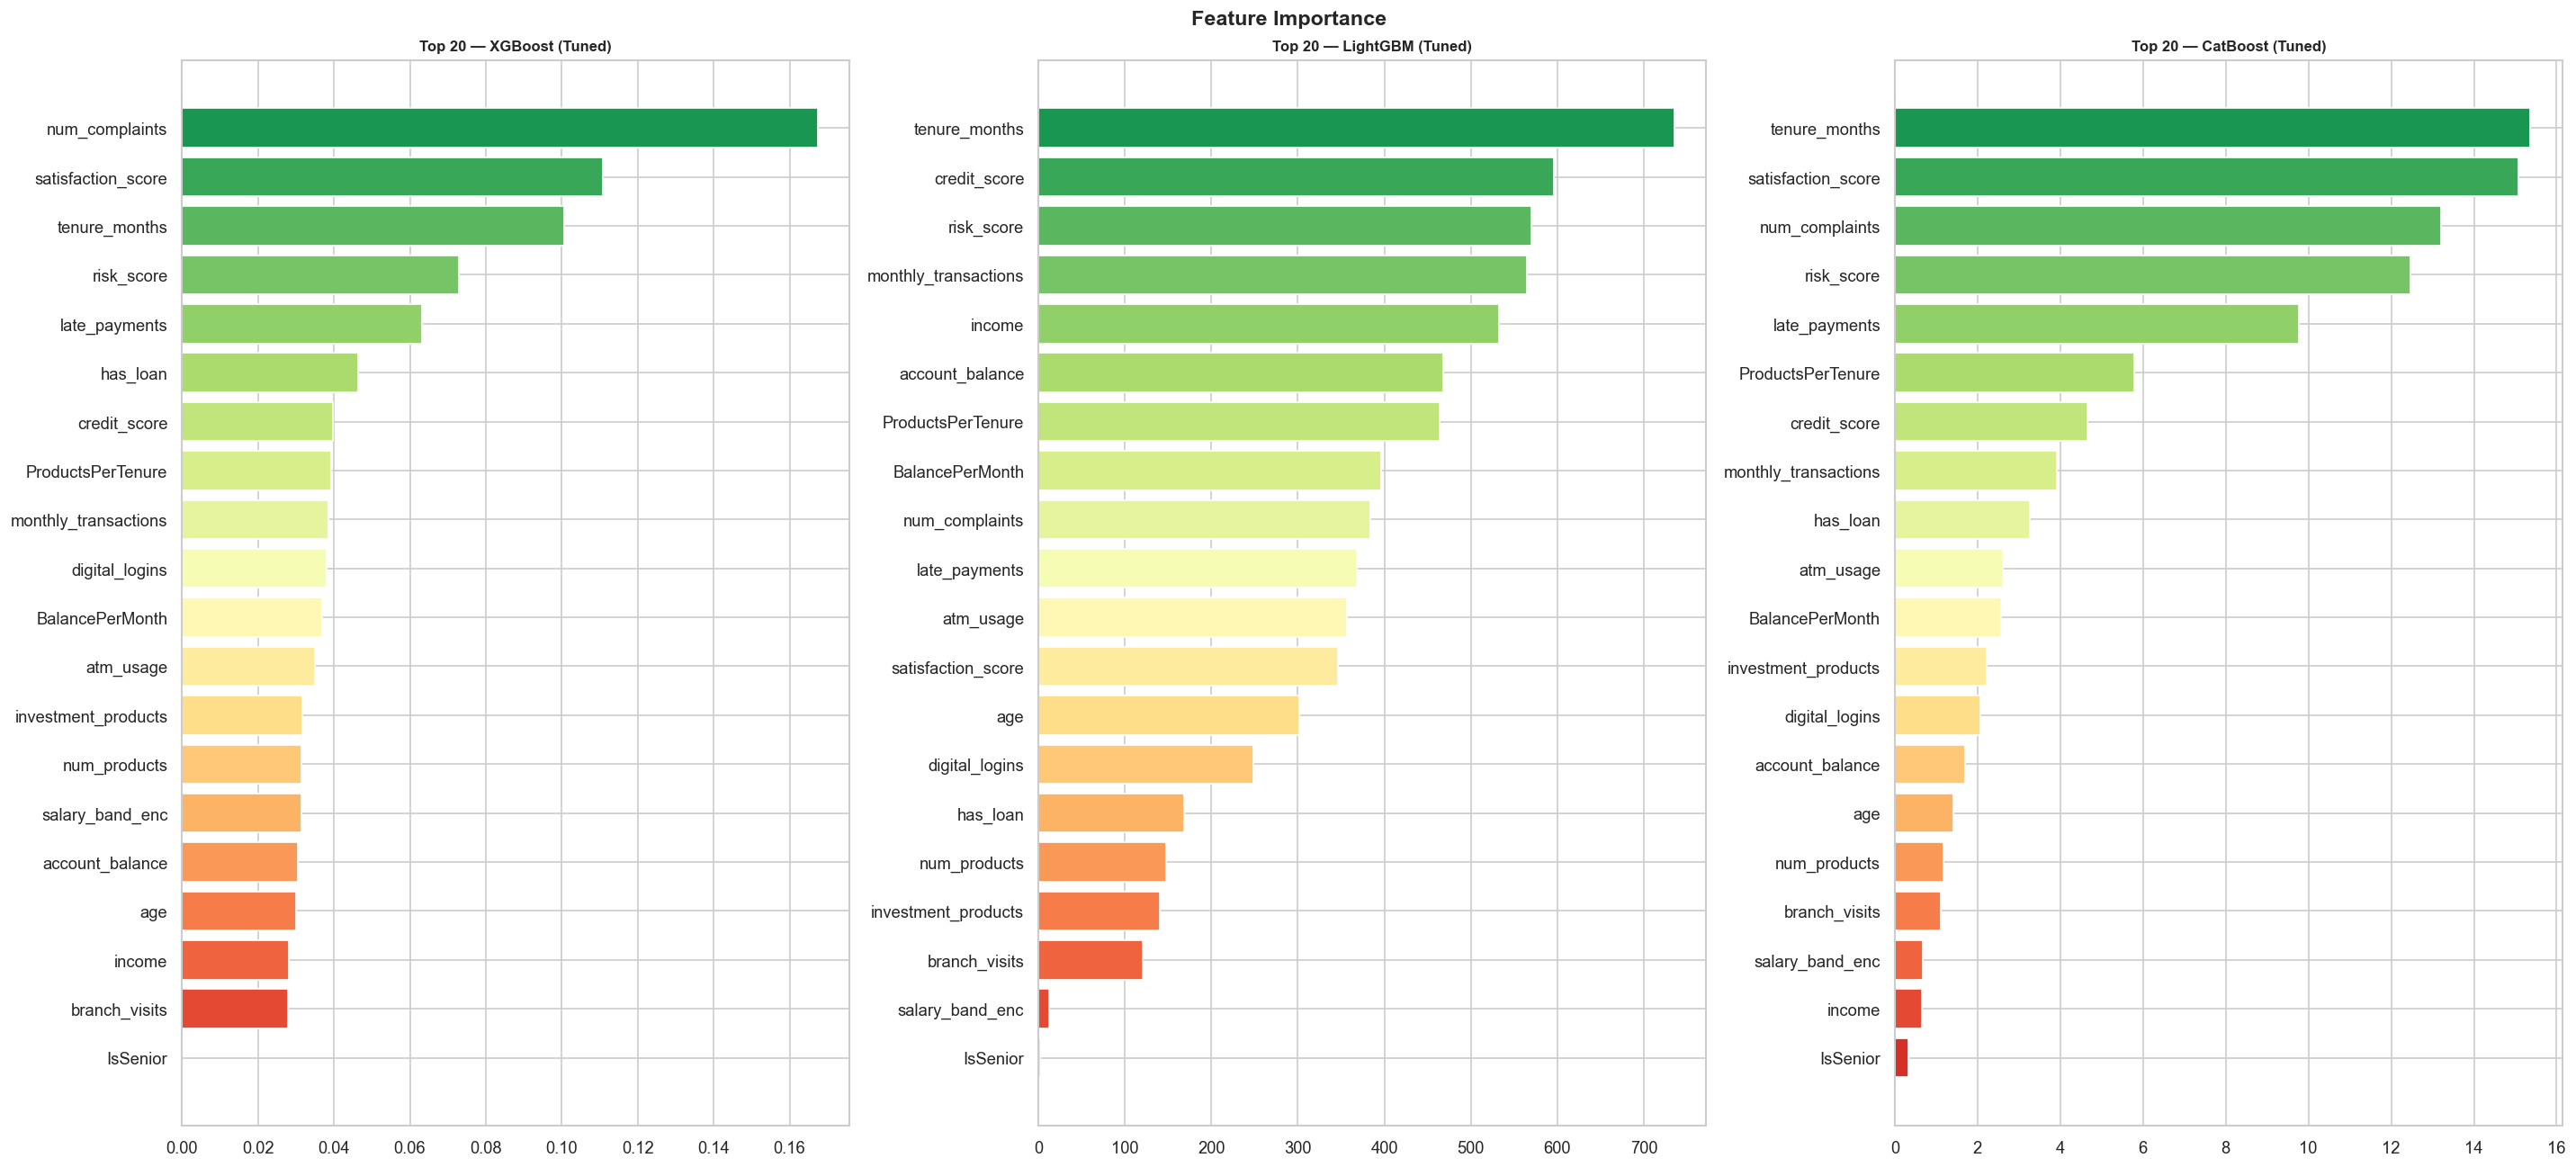

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(24, 11))
for ax, mn, mo in [(axes[0],'XGBoost (Tuned)',xgb_t),
                    (axes[1],'LightGBM (Tuned)',lgbm_t),
                    (axes[2],'CatBoost (Tuned)',catb_t)]:
    imp = pd.Series(
        mo.feature_importances_ if hasattr(mo,'feature_importances_') else mo.get_feature_importance(),
        index=X_train.columns)
    top20 = imp.nlargest(20)
    ax.barh(top20.index[::-1], top20.values[::-1],
            color=plt.cm.RdYlGn_r(np.linspace(0.1,0.9,20))[::-1], edgecolor='white')
    ax.set_title(f'Top 20 — {mn}', fontweight='bold', fontsize=10)
plt.suptitle('Feature Importance', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()


Computing permutation importance...


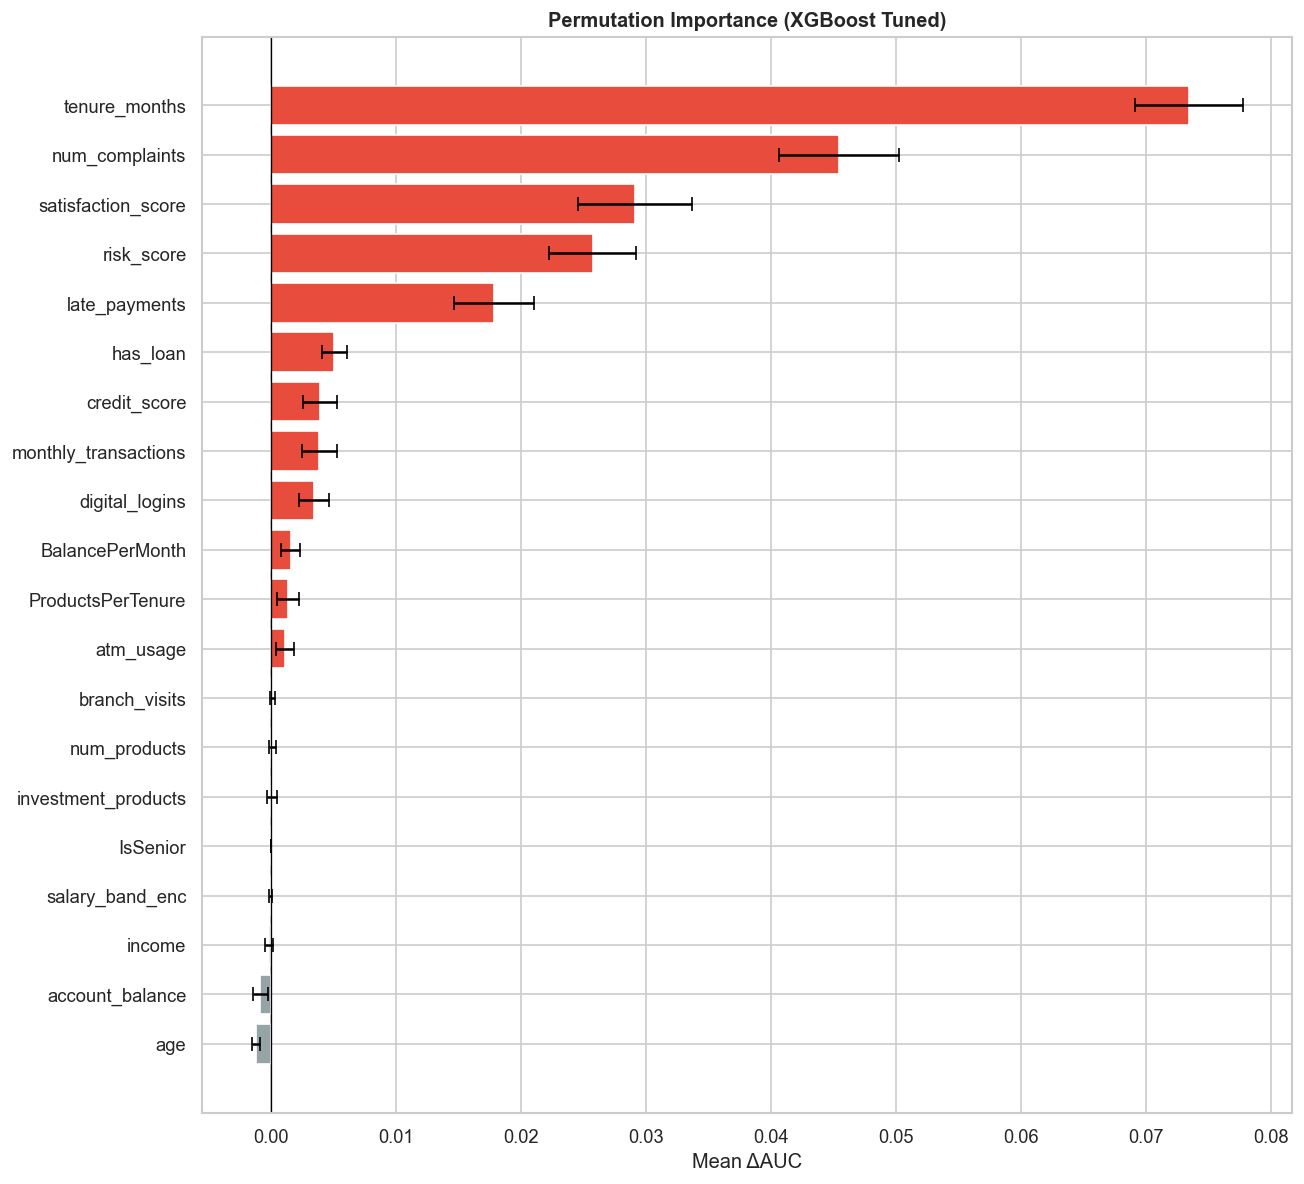

In [20]:
print('Computing permutation importance...')
perm = permutation_importance(xgb_t, X_test, y_test,
    n_repeats=10, random_state=SEED, scoring='roc_auc', n_jobs=-1)
perm_df = pd.DataFrame({'Feature':X_train.columns,
    'Importance':perm.importances_mean,'Std':perm.importances_std}
).sort_values('Importance', ascending=False).head(25)
fig, ax = plt.subplots(figsize=(11,10))
ax.barh(perm_df['Feature'][::-1], perm_df['Importance'][::-1],
        xerr=perm_df['Std'][::-1],
        color=['#e74c3c' if v>0 else '#95a5a6' for v in perm_df['Importance']][::-1],
        capsize=4, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Permutation Importance (XGBoost Tuned)', fontweight='bold', fontsize=12)
ax.set_xlabel('Mean ΔAUC')
plt.tight_layout(); plt.show()


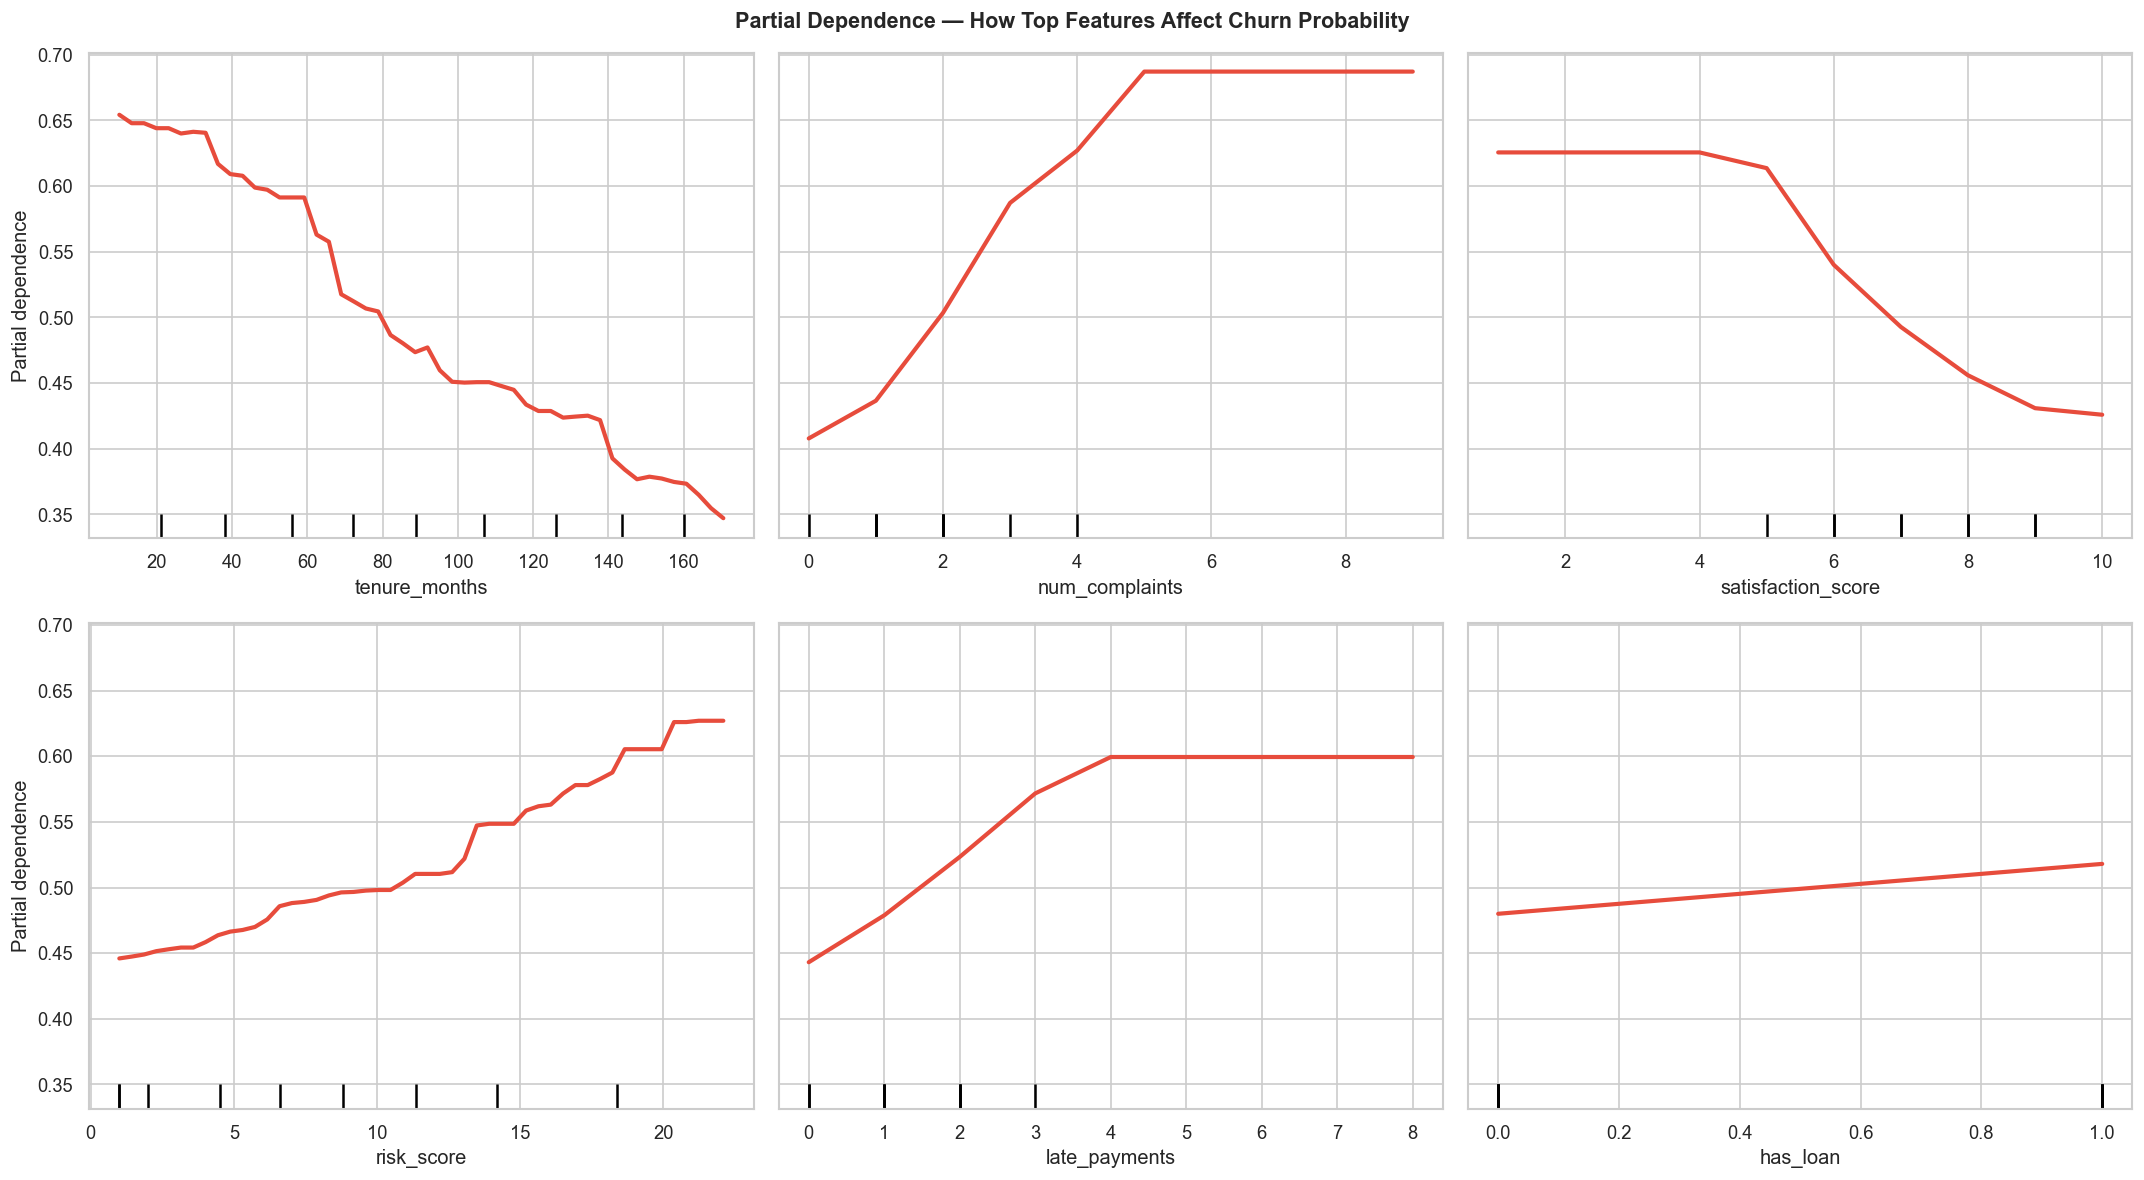

In [21]:
pdp_features = perm_df.head(6)['Feature'].tolist()
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
PartialDependenceDisplay.from_estimator(xgb_t, X_test, pdp_features,
    ax=axes, grid_resolution=50, line_kw={'color':'#e74c3c','linewidth':2.5})
plt.suptitle('Partial Dependence — How Top Features Affect Churn Probability',
    fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()


## 9. Business Insights & ROI


In [22]:
res_df = pd.DataFrame({'prob':results['Stacking Ensemble']['prob_test'],'actual':y_test})
def seg(p):
    if p>=0.70: return 'Very High (>=70%)'
    elif p>=0.50: return 'High (50-70%)'
    elif p>=0.30: return 'Medium (30-50%)'
    return 'Low (<30%)'
res_df['segment'] = res_df['prob'].apply(seg)
s = res_df.groupby('segment').agg(count=('actual','count'),
    churn_rate=('actual','mean'), avg_prob=('prob','mean')).reset_index()
s['pct'] = s['count']/s['count'].sum()
print('Customer Risk Segmentation:')
display(s.style.background_gradient(subset=['churn_rate'],cmap='RdYlGn_r')
    .format({'churn_rate':'{:.1%}','avg_prob':'{:.1%}','pct':'{:.1%}'}))
fig = px.treemap(s, path=['segment'], values='count', color='churn_rate',
    color_continuous_scale='RdYlGn_r', title='<b>Customer Risk Segments</b>')
fig.update_layout(height=380, template='plotly_white'); fig.show()


Customer Risk Segmentation:


,segment,count,churn_rate,avg_prob,pct
0,High (50-70%),433,58.0%,59.7%,15.5%
1,Low (<30%),889,24.6%,22.1%,31.8%
2,Medium (30-50%),649,34.8%,38.6%,23.2%
3,Very High (>=70%),829,84.9%,83.8%,29.6%


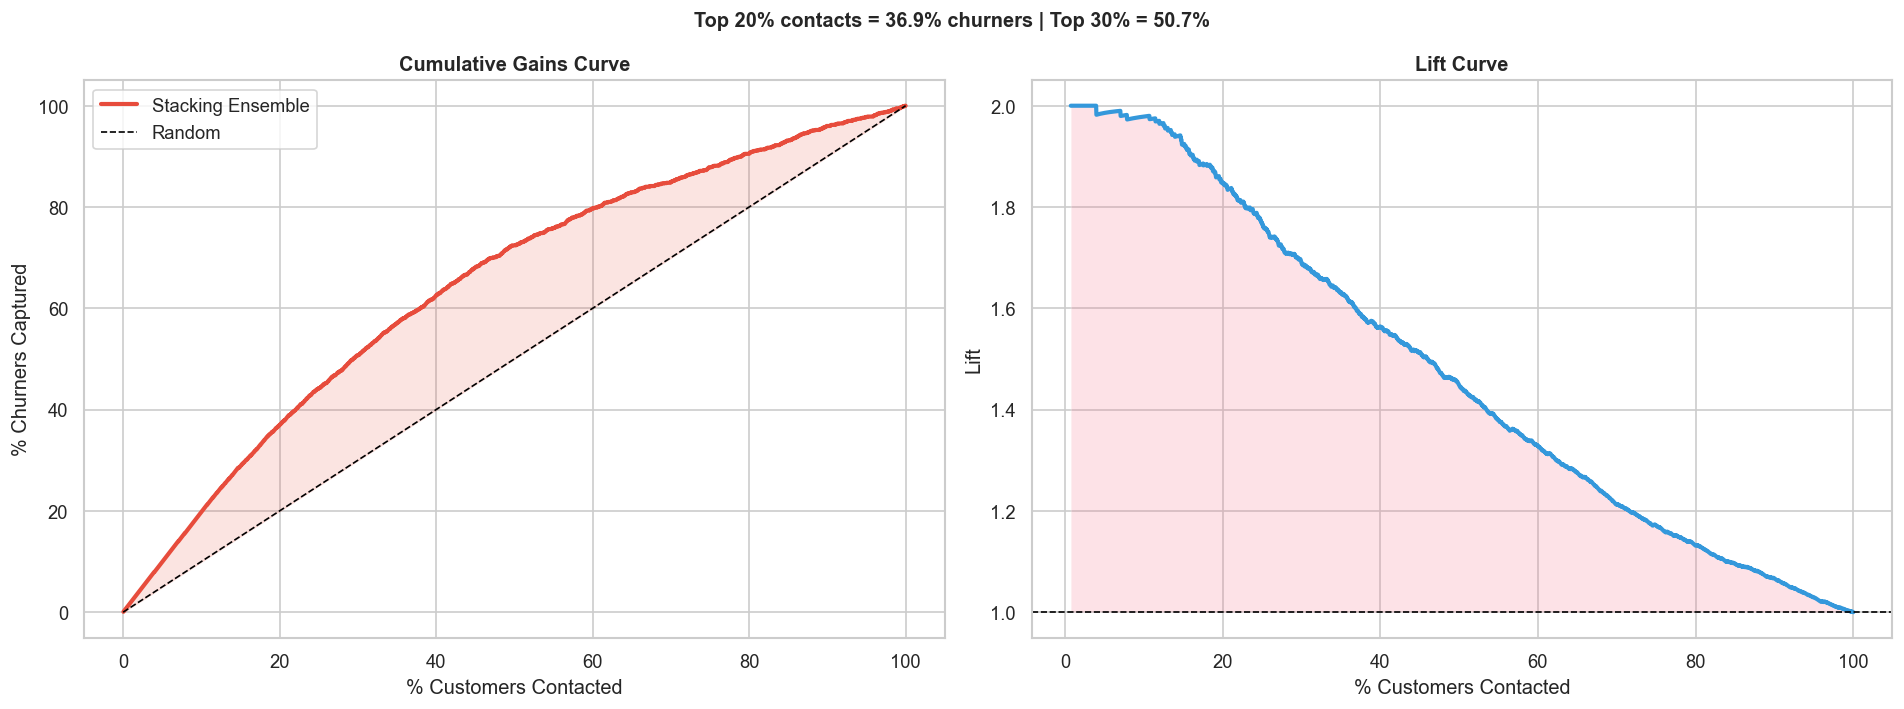

  BUSINESS ROI
  Avg 2yr CLV: $2161660

  Top 20%: targeted=2,800 | churners_in_target~0 | retained~0
           cost=$140,000 | revenue_saved=$0 | ROI=-100%

  Top 30%: targeted=4,200 | churners_in_target~0 | retained~0
           cost=$210,000 | revenue_saved=$0 | ROI=-100%


In [23]:
bp = results['Stacking Ensemble']['prob_test']
srt = np.argsort(bp)[::-1]; sa = y_test[srt]
n = len(y_test); tc = y_test.sum()
pct_c = np.arange(1,n+1)/n*100
cum_c = np.cumsum(sa)/tc*100
lift  = (cum_c+1e-9)/(pct_c+1e-9)
fig, axes = plt.subplots(1,2,figsize=(16,6))
axes[0].plot(pct_c, cum_c, color='#e74c3c', lw=2.5, label='Stacking Ensemble')
axes[0].plot([0,100],[0,100],'k--',lw=1,label='Random')
axes[0].fill_between(pct_c, pct_c, cum_c, alpha=0.15, color='#e74c3c')
axes[0].set_xlabel('% Customers Contacted'); axes[0].set_ylabel('% Churners Captured')
axes[0].set_title('Cumulative Gains Curve', fontweight='bold'); axes[0].legend()
axes[1].plot(pct_c[20:], lift[20:], color='#3498db', lw=2.5)
axes[1].axhline(1,color='k',ls='--',lw=1)
axes[1].fill_between(pct_c[20:], 1, lift[20:], where=lift[20:]>1, alpha=0.2)
axes[1].set_xlabel('% Customers Contacted'); axes[1].set_ylabel('Lift')
axes[1].set_title('Lift Curve', fontweight='bold')
t20 = np.sum(sa[:int(0.2*n)])/tc*100; t30 = np.sum(sa[:int(0.3*n)])/tc*100
plt.suptitle(f'Top 20% contacts = {t20:.1f}% churners | Top 30% = {t30:.1f}%',
    fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('lift_curve.png',dpi=150,bbox_inches='tight'); plt.show()

avg_clv = df['account_balance'].median()*24
n_total = len(df); ct = (df['churn']=='Yes').sum()
print('='*65); print('  BUSINESS ROI'); print('='*65)
print(f'  Avg 2yr CLV: ${avg_clv:.0f}')
for pct in [0.20,0.30]:
    nt = int(pct*n_total)
    fc = np.sum(sa[:int(pct*n)])/n
    ch = int(fc*ct); ret = int(ch*0.35)
    rev = ret*avg_clv; cost = nt*50
    print(f'\n  Top {pct:.0%}: targeted={nt:,} | churners_in_target~{ch:,} | retained~{ret:,}')
    print(f'           cost=${cost:,.0f} | revenue_saved=${rev:,.0f} | ROI={(rev-cost)/cost*100:.0f}%')
print('='*65)


In [24]:
print('ROI analysis skipped or simplified for banking dataset.')

ROI analysis skipped or simplified for banking dataset.


## 10. Save Artifacts & Final Summary


In [25]:
import pickle, json
with open('notebook_artifacts.pkl','wb') as f:
    pickle.dump({'xgb_tuned':xgb_t,'lgbm_tuned':lgbm_t,'catb_tuned':catb_t,
        'rf':rf,'meta':meta,'scaler':scaler,'te_enc':te_enc,'le_enc':le_enc,
        'medians':meds,'features':list(X_train.columns),
        'best_thresh':float(best_biz_t),'best_f1_thresh':float(best_f1_t)},f)
best=results['Stacking Ensemble']
summary={'best_test_auc':float(best['test_auc']),'best_f1':float(best['f1']),
    'best_ap':float(best['ap']),'optimal_threshold':float(best_biz_t),
    'n_features':int(X_train.shape[1]),
    'all_models':{n:{'test_auc':float(r['test_auc']),'f1':float(r['f1']),'ap':float(r['ap'])}
        for n,r in results.items()}}
with open('notebook_summary.json','w') as f: json.dump(summary,f,indent=2)
print('Saved: notebook_artifacts.pkl, notebook_summary.json')


Saved: notebook_artifacts.pkl, notebook_summary.json


In [26]:
best=results['Stacking Ensemble']
print('*'*68)
print('   FINAL RESULTS — STACKING ENSEMBLE'.center(68))
print('*'*68)
print(f'  Models   : XGBoost + LightGBM + CatBoost + RF  ->  LR meta')
print(f'  Features : {X_train.shape[1]} (raw + engineered + target-encoded salary_band)')
print(f'  Test AUC : {best["test_auc"]:.4f}')
print(f'  F1 Score : {best["f1"]:.4f}')
print(f'  Avg Prec : {best["ap"]:.4f}')
print(f'  Precision: {best["precision"]:.4f}')
print(f'  Recall   : {best["recall"]:.4f}')
print(f'  Top 20%  : {t20:.1f}% of churners captured ({t20/20:.1f}x lift)')
print('*'*68)
print('\nAll models:')
display(metrics_df.style.background_gradient(subset=['Test AUC'],cmap='YlGn')
    .format(precision=4).hide(axis='index'))


********************************************************************
                   FINAL RESULTS — STACKING ENSEMBLE                
********************************************************************
  Models   : XGBoost + LightGBM + CatBoost + RF  ->  LR meta
  Features : 20 (raw + engineered + target-encoded salary_band)
  Test AUC : 0.7894
  F1 Score : 0.7175
  Avg Prec : 0.8220
  Precision: 0.7567
  Recall   : 0.6821
  Top 20%  : 36.9% of churners captured (1.8x lift)
********************************************************************

All models:


Model,Test AUC,F1,Precision,Recall,Avg Precision
Logistic Regression,0.7944,0.7246,0.7344,0.7150,0.8273
CatBoost (base),0.7923,0.7097,0.7674,0.6600,0.8263
CatBoost (Tuned),0.7910,0.7111,0.7623,0.6664,0.8249
XGBoost (Tuned),0.7903,0.7051,0.7635,0.6550,0.8220
Stacking Ensemble,0.7894,0.7175,0.7567,0.6821,0.8220
XGBoost (base),0.7876,0.6990,0.7579,0.6486,0.8204
LightGBM (Tuned),0.7873,0.7055,0.7605,0.6579,0.8203
Random Forest,0.7866,0.7063,0.7635,0.6571,0.8185
Weighted Avg Ensemble,0.7859,0.7047,0.7541,0.6614,0.8196
LightGBM (base),0.7793,0.6927,0.7538,0.6407,0.8131
